In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns

#DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
#DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)
Y2H_COLOR_LIGHT = "#EE99AA" #color for static (in complex)
Y2H_COLOR_DARK  = "#994455" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [2]:
# load the datasets with node centrality information and get nodes in both
nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")

# --- Flip sign of cagiada-dG so downstream code uses the corrected values ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

Remove proteins with low plddt, are membrane proteins and/or signal peptide

In [3]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [4]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10

y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in Y2H data is 0.00297; there are 116 hubs and 866 non hubs


## Supplement Fig 5A

* Create Box plots comparing protein turnover half-lives (t1/2, min) between static and dynamic hub proteins (high degree centrality) in the Y2H network

In [5]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=42):
    """
    Nonparametric bootstrap CI for the median
    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan
    
    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=np.float32)
    
    for b in trange(B, desc="Bootstrapping medians", leave=False):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)
    
    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

# Define Y2H degree hubs (top 10%)
y2h_hubs = filtered_nodes[
    filtered_nodes['Y2H_degree_centrality'] >= filtered_nodes['Y2H_degree_centrality'].quantile(0.9)
].copy()

# Ensure boolean
y2h_hubs['in_complex'] = y2h_hubs['in_complex'].astype(bool)

# Split into Static (in complex) vs Dynamic (not in complex)
static_vals = y2h_hubs[y2h_hubs['in_complex']]['Villen_halflife_min']\
    .replace([np.inf, -np.inf], np.nan).dropna()
dynamic_vals = y2h_hubs[~y2h_hubs['in_complex']]['Villen_halflife_min']\
    .replace([np.inf, -np.inf], np.nan).dropna()

# NEW VARIABLE 
groups_step3 = [
    ("Static", static_vals, Y2H_COLOR_LIGHT),
    ("Dynamic", dynamic_vals, Y2H_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (Y2H) ===")
for label, vals, _ in groups_step3:
    print(f"{label:8}: n = {len(vals)}")

# Bootstrapped medians
print("\n=== Bootstrapped median half-life (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []
for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:8}: median = {m:.1f} min, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (Y2H) ===
Static  : n = 40
Dynamic : n = 44

=== Bootstrapped median half-life (95% CI) ===


Static  : median = 145.5 min, 95% CI = (131.7, 152.7)


Dynamic : median = 154.5 min, 95% CI = (121.2, 167.7)


In [6]:
# Mann-Whitney U test
u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='greater')
print("\n=== Mann–Whitney U test (Static vs Dynamic hubs) ===")
print(f"n(Static) = {len(static_vals)}, n(Dynamic) = {len(dynamic_vals)}")
print(f"median(Static) = {np.median(static_vals):.1f}, median(Dynamic) = {np.median(dynamic_vals):.1f}")
print(f"U = {u_stat:.1f}, p = {p_val:.2g}")
stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
print(f"Significance: {stars}")


=== Mann–Whitney U test (Static vs Dynamic hubs) ===
n(Static) = 40, n(Dynamic) = 44
median(Static) = 145.5, median(Dynamic) = 154.5
U = 820.5, p = 0.7
Significance: N.S.


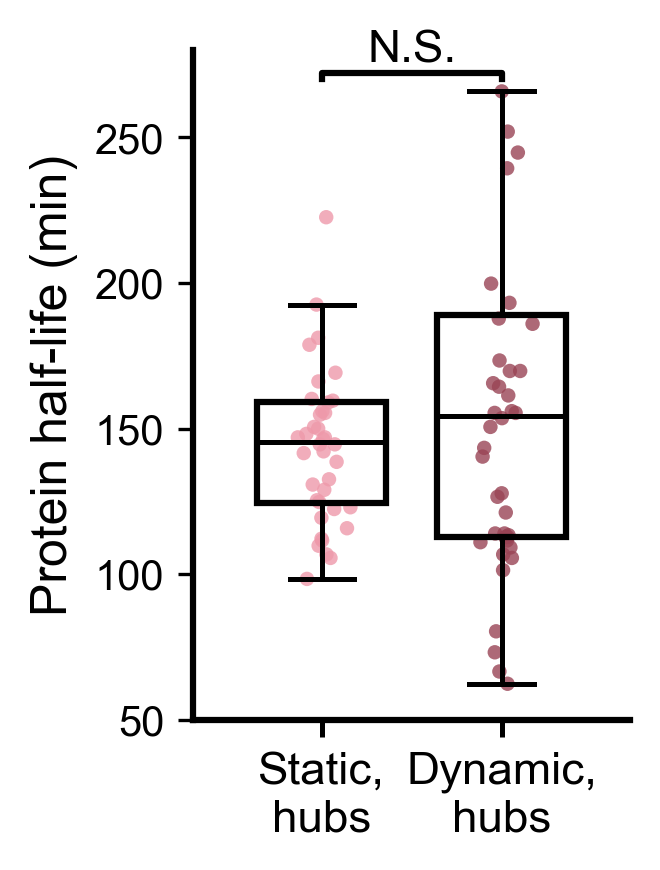

In [7]:
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 2    
    ax.plot([x1, x1, x2, x2],
            [y,  y_top, y_top, y],
            lw=1.5, 
            c="black",
            clip_on=False) 
    ax.text((x1 + x2)/2, 
            y_top + 1.05, 
            text,
            ha="center", 
            va="bottom", 
            fontsize=11,
           zorder=4)

# Prepare plot
fig, ax = plt.subplots(figsize=(2.3, 3))

positions = [1.0, 1.7]
group_data = [static_vals, dynamic_vals]
group_colors = [Y2H_COLOR_LIGHT, Y2H_COLOR_DARK]

# Scatter (jittered)
for pos, (vals, color) in zip(positions, zip(group_data, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.04, size=len(vals))
    ax.scatter(x_jitter, vals, s=12, color=color,
               alpha=0.8, edgecolor="none", zorder=2)

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_data,
    tick_labels=["Static,\nBottlenecks", "Dynamic,\nNon-\nbottlenecks"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)
        
# === 3. X-axis labels ===
ax.set_xticks(positions)
ax.set_xticklabels(["Static,\nhubs", "Dynamic,\nhubs"],
                       fontsize=11)
ax.tick_params(axis="x", length=4, width=1.2)

labs = ax.get_xticklabels()
labs[0].set_color("black")
labs[1].set_color("black")

# Styling
#ax.set_yscale("log")
ax.set_ylim(50, 280)
#ax.minorticks_off()
ax.set_ylabel('Protein half-life (min)', fontsize=12)
bracket_y = 260
bracket_h = 2

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Significance bracket
add_bracket_with_text(ax, positions[0], positions[1], y=270, text=stars)

# Bottom group label: "Y2H" style
trans = ax.get_xaxis_transform()
#ax.plot([1.0, 1.7], [-0.26, -0.26], transform=trans, clip_on=False, color=Y2H_COLOR, lw=2.5)
#ax.text(1.4, -0.28, "Y2H", transform=trans, ha="center", va="top",
#        fontsize=11, fontweight="bold", color=Y2H_COLOR)

plt.tight_layout()
plt.savefig("Supp5-A.svg", dpi=400, bbox_inches='tight')
plt.show()

## Supplement Fig 5B-E

* Create Box plots comparing stability metrices and melting point between static and dynamic hub proteins (high degree centrality) in the Y2H network

In [8]:
# === Prepare Y2H Degree Hubs (top 10%) ===
y2h_hubs = filtered_nodes[
    filtered_nodes['Y2H_degree_centrality'] >= filtered_nodes['Y2H_degree_centrality'].quantile(0.9)
].copy()
y2h_hubs['in_complex'] = y2h_hubs['in_complex'].astype(bool)

# === Define the 4 stability metrics ===
stability_list = [
    ("Ghosh-Dill-dG",            "Ghosh-Dill ΔG"),
    ("cagiada-dG",               "Cagiada ΔG"),
    ("Rosetta_best_total_score", "Rosetta Total Score"),
    ("meltome-melting-point",    "Melting Point Tm (°C)"),
]

# === Extract clean values: Static vs Dynamic hubs ===
groups_step4 = []
for col, name in stability_list:
    if col == 'meltome-melting-point':
        data = y2h_hubs[y2h_hubs['meltome-fit-R2'] >= 0.9]   # High-quality meltome only
    else:
        data = y2h_hubs
    
    static_vals  = data[data['in_complex']][col].replace([np.inf, -np.inf], np.nan).dropna()
    dynamic_vals = data[~data['in_complex']][col].replace([np.inf, -np.inf], np.nan).dropna()
    
    groups_step4.append((name, static_vals, dynamic_vals))

print("=== BOOTSTRAPPED MEDIANS (95% CI) – Static vs Dynamic in Degree Hubs ===\n")
for name, static_vals, dynamic_vals in groups_step4:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data")
        continue
    m_s, lo_s, hi_s = bootstrap_ci_median(static_vals, random_state=42)
    m_d, lo_d, hi_d = bootstrap_ci_median(dynamic_vals, random_state=42)
    print(f"{name:30} | Static:  {m_s:6.2f} [{lo_s:.1f}, {hi_s:.1f}]  (n={len(static_vals)})")
    print(f"{'':30} | Dynamic: {m_d:6.2f} [{lo_d:.1f}, {hi_d:.1f}]  (n={len(dynamic_vals)})\n")

=== BOOTSTRAPPED MEDIANS (95% CI) – Static vs Dynamic in Degree Hubs ===



Ghosh-Dill ΔG                  | Static:  -10.93 [-11.9, -10.2]  (n=61)
                               | Dynamic: -11.82 [-12.8, -9.9]  (n=55)



Cagiada ΔG                     | Static:  -18.18 [-21.0, -15.9]  (n=61)
                               | Dynamic: -20.48 [-23.0, -18.2]  (n=55)



Rosetta Total Score            | Static:  -1058.31 [-1307.1, -961.8]  (n=61)
                               | Dynamic: -1153.13 [-1364.8, -872.4]  (n=55)



Melting Point Tm (°C)          | Static:   48.61 [47.1, 50.0]  (n=28)
                               | Dynamic:  49.99 [49.2, 52.3]  (n=34)



In [9]:
print("\n=== MANN–WHITNEY U TESTS (Static vs Dynamic in Degree Hubs) ===\n")

results = []
for name, static_vals, dynamic_vals in groups_step4:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data for test")
        results.append((name, np.nan, 1.0))
        continue
    
    u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='greater')
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
    
    print(f"{name:30} | U = {u_stat:6.0f}, p = {p_val:.2g} {stars}")
    print(f"{'':32} Static median = {np.median(static_vals):.2f}, Dynamic = {np.median(dynamic_vals):.2f}\n")
    
    results.append((name, u_stat, p_val))


=== MANN–WHITNEY U TESTS (Static vs Dynamic in Degree Hubs) ===

Ghosh-Dill ΔG                  | U =   1738, p = 0.37 N.S.
                                 Static median = -10.93, Dynamic = -11.82

Cagiada ΔG                     | U =   1999, p = 0.038 *
                                 Static median = -18.18, Dynamic = -20.48

Rosetta Total Score            | U =   1788, p = 0.27 N.S.
                                 Static median = -1058.31, Dynamic = -1153.13

Melting Point Tm (°C)          | U =    350, p = 0.96 N.S.
                                 Static median = 48.61, Dynamic = 49.99



/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_35271/3016009143.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: Supp5-B-E.1.svg


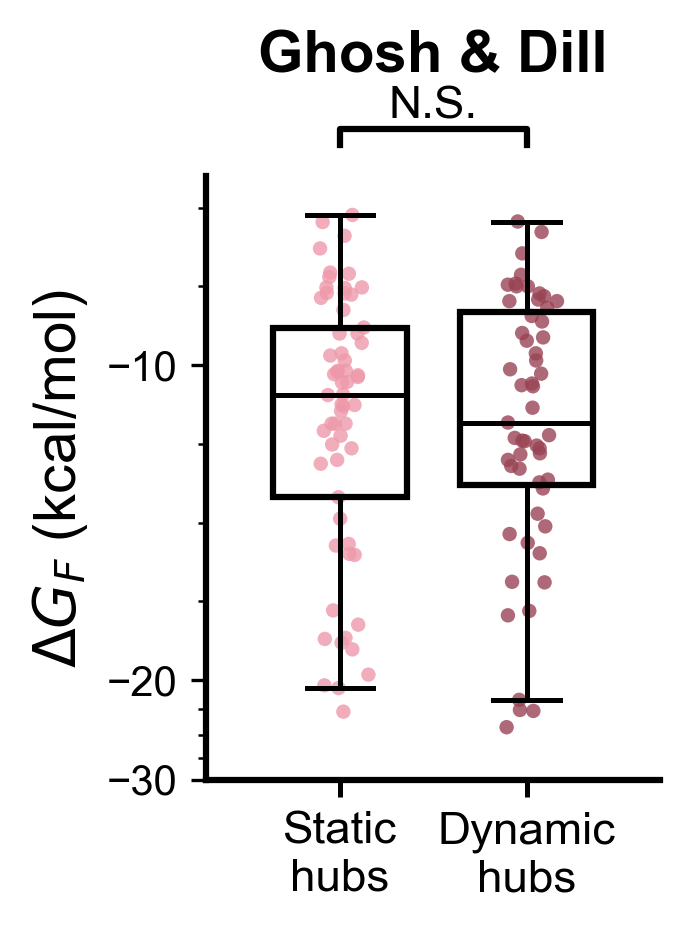

Saved: Supp5-B-E.2.svg


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_35271/3016009143.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


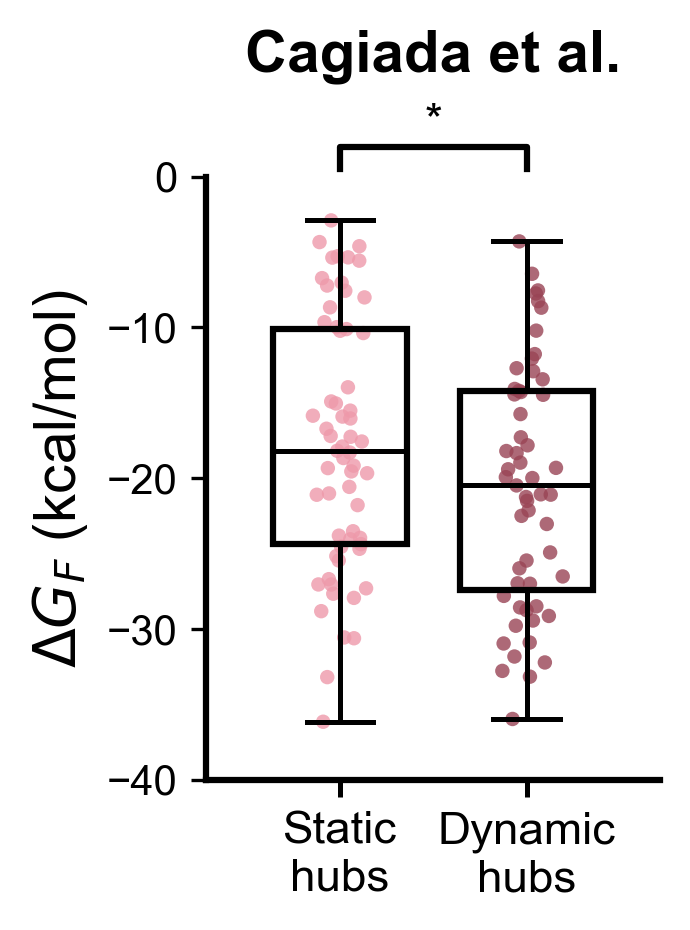

Saved: Supp5-B-E.3.svg


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_35271/3016009143.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


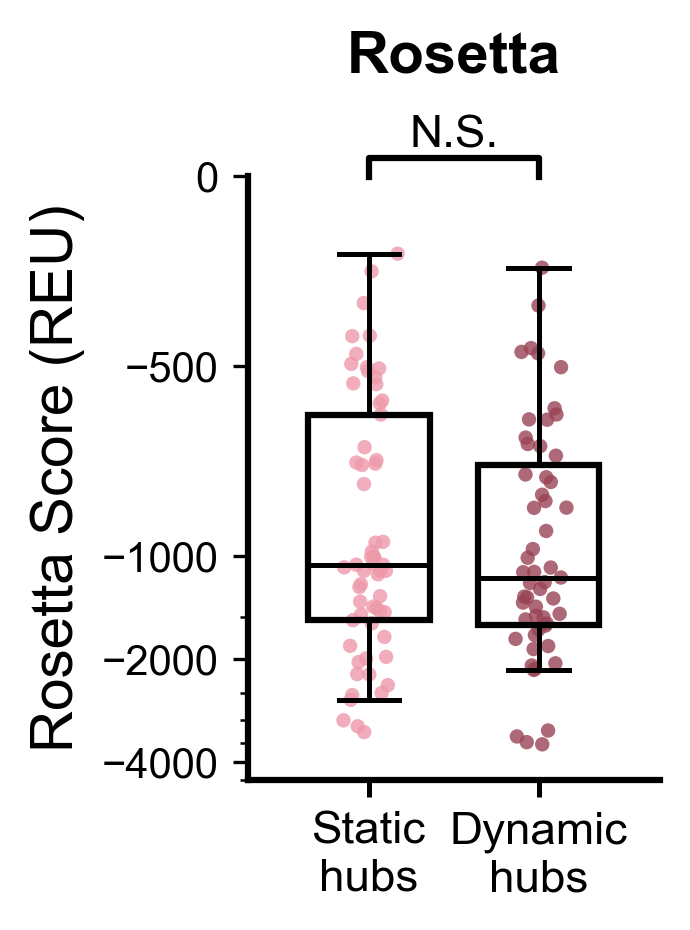

/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_35271/3016009143.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: Supp5-B-E.4.svg


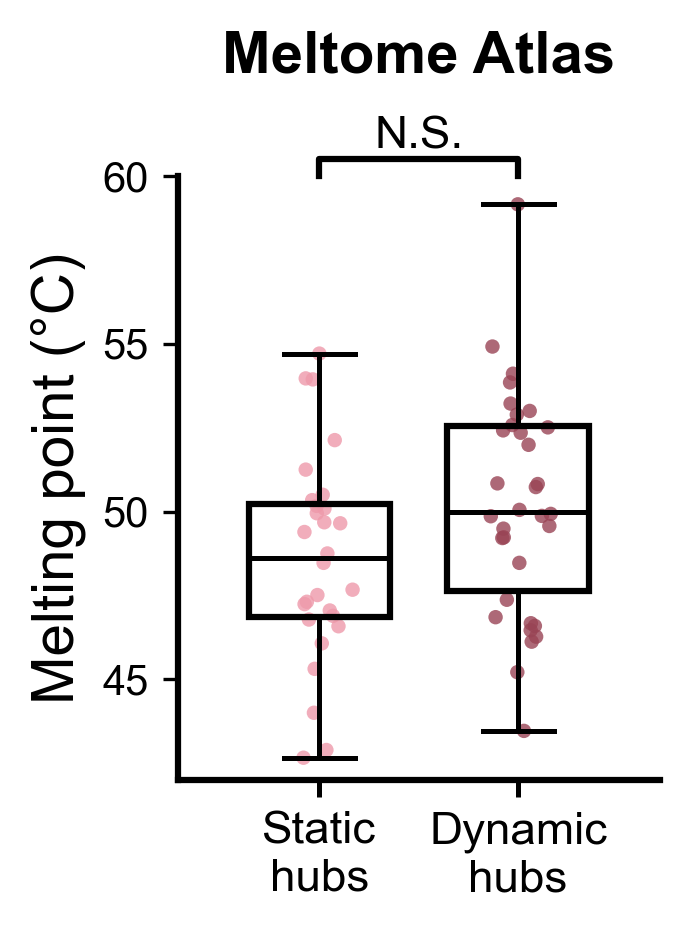

In [10]:
from matplotlib.ticker import AutoMinorLocator
def draw_significance(ax, x1, x2, y, h, text):
    """
    Draws a straight bracket + text at EXACT y position and height h.
    - x1, x2 = x-coordinates of the two groups
    - y = vertical position of the bracket
    - h = height of the vertical bracket lines
    - text = significance stars
    """
    ax.plot([x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5, color="black", clip_on=False)
    
    ax.text((x1 + x2) / 2, y + h*1.1, text,
            ha="center", va="bottom",
            fontsize=11)


def base_box_scatter(ax, static_vals, dynamic_vals):
    positions = [1.0, 1.7]

    # === 1. Scatter ===
    for pos, vals, color in zip(
        positions,
        [static_vals, dynamic_vals],
        [Y2H_COLOR_LIGHT, Y2H_COLOR_DARK]
    ):
        x_jitter = pos + np.random.normal(0, 0.05, len(vals))
        ax.scatter(x_jitter, vals, s=12, alpha=0.8,
                   color=color, edgecolor="none", zorder=2)

    # === 2. Boxplot ===
    bp = ax.boxplot(
        [static_vals.values, dynamic_vals.values],
        positions=positions,
        labels=["Static", "Dynamic"],
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        zorder=3
    )

    for box in bp["boxes"]:
        box.set_facecolor("none")
        box.set_edgecolor("black")
        box.set_linewidth(1.5)

    for element in ["whiskers", "caps", "medians"]:
        plt.setp(bp[element], color="black", linewidth=1.2)

    # === 3. X-axis labels ===
    ax.set_xticks(positions)
    ax.set_xticklabels(["Static\nhubs", "Dynamic\nhubs"],
                       fontsize=11)
    ax.tick_params(axis="x", length=4, width=1.2)

    labs = ax.get_xticklabels()
    labs[0].set_color("black")
    labs[1].set_color("black")

    #  === 4. Spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    return positions

figure_counter = 1
for stab_name, static_vals, dynamic_vals in groups_step4:

    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print("Skipping:", stab_name)
        continue

    fig, ax = plt.subplots(figsize=(2.4, 3.2))

    #  === 5. Base scatter+boxplot
    positions = base_box_scatter(ax, static_vals, dynamic_vals)
    ax.set_ylabel(stab_name, fontsize=11)
    ax.set_title("", fontsize=11)

    #  === 6. Metric-specific axis rules
    if "Rosetta" in stab_name:
        #ax.set_yscale("symlog", linthresh=10)
        ax.set_ylabel("Rosetta Score (REU)", fontsize=14)
        ax.set_title("Rosetta", fontweight='bold')
        ax.set_yscale("symlog", linthresh=1000)
        ax.set_ylim(-4500, 0)
        ax.set_yticks([-4000, -2000, -1000, -500, 0])
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
        #ax.minorticks_on()
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        bracket_y = -2   
        bracket_h = 50 

    elif "Meltome" in stab_name or "Tm" in stab_name:
        ax.set_ylabel(r"Melting point (°C)", fontsize=14)
        ax.set_title("Meltome Atlas", fontweight='bold')
        ax.set_ylim(42, 60)
        ax.set_yticks([45, 50, 55, 60])
        bracket_y = 60    
        bracket_h = 0.5

    elif "Cagiada" in stab_name:
        ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=14)
        ax.set_title("Cagiada et al.", fontweight='bold')
        ax.set_ylim(-40, 0)
        ax.set_yticks([0, -10, -20, -30, -40])
        bracket_y = 0.5
        bracket_h = 1.5
        
    elif "Ghosh-Dill" in stab_name:
        ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=14)
        ax.set_title("Ghosh & Dill", fontweight='bold')
        ax.set_yscale("symlog", linthresh=20)
        ax.set_ylim(-30, -4)
        ax.set_yticks([-10, -20, -30])
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
        #ax.minorticks_on()
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        bracket_y = -3
        bracket_h = 0.5

    #  === 7. Significance stars
    p_val = [r[2] for r in results if r[0] == stab_name][0]
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
    draw_significance(ax, positions[0], positions[1], bracket_y, bracket_h, stars)

    #  === 8. Y2H label below plot
    trans = ax.get_xaxis_transform()
    #ax.plot([1.0, 1.7], [-0.24, -0.24], transform=trans,
    #        clip_on=False, color=Y2H_COLOR, lw=1.5)
    #ax.text(1.4, -0.26, "Y2H", transform=trans,
    #        ha="center", va="top", fontsize=10,
    #        fontweight="bold", color=Y2H_COLOR)

    # === 9. Save
    plt.tight_layout()
    out = f"Supp5-B-E.{figure_counter}.svg"
    plt.savefig(out, dpi=400, bbox_inches="tight")
    print("Saved:", out)

    figure_counter += 1
    plt.show()

In [11]:
# determine which nodes are hubs based on percentile cutoff for betweenness centrality
cut = 0.10
#ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
#ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
#ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

y2h_threshold = filtered_nodes['Y2H_betweenness_centrality'].quantile(1 - cut)
y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_betweenness_centrality'] >= y2h_threshold]
y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_betweenness_centrality'] <  y2h_threshold]

#print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in Y2H data is 0.00399; there are 99 hubs and 883 non hubs


## Supplement Fig F

* Create Box plots comparing protein turnover half-lives (t1/2, min) between static and dynamic bottleneck proteins (high betweenness centrality) in the Y2H network

In [12]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=42):
    """
    Nonparametric bootstrap CI for the median
    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan
    
    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=np.float32)
    
    for b in trange(B, desc="Bootstrapping medians", leave=False):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)
    
    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper

In [13]:
# Define Y2H betweenness hubs (top 10%)
y2h_hubs = filtered_nodes[
    filtered_nodes['Y2H_betweenness_centrality'] >= filtered_nodes['Y2H_betweenness_centrality'].quantile(0.9)
].copy()

# Ensure boolean
y2h_hubs['in_complex'] = y2h_hubs['in_complex'].astype(bool)

# Split into Static (in complex) vs Dynamic (not in complex)
static_vals = y2h_hubs[y2h_hubs['in_complex']]['Villen_halflife_min']\
    .replace([np.inf, -np.inf], np.nan).dropna()
dynamic_vals = y2h_hubs[~y2h_hubs['in_complex']]['Villen_halflife_min']\
    .replace([np.inf, -np.inf], np.nan).dropna()

# NEW VARIABLE 
groups_step3 = [
    ("Static", static_vals, Y2H_COLOR_LIGHT),
    ("Dynamic", dynamic_vals, Y2H_COLOR_DARK),
]

print("=== Protein counts in Betweenness Hubs (Y2H) ===")
for label, vals, _ in groups_step3:
    print(f"{label:8}: n = {len(vals)}")

# Bootstrapped medians
print("\n=== Bootstrapped median half-life (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []
for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:8}: median = {m:.1f} min, 95% CI = ({lo:.1f}, {hi:.1f})")

# Mann-Whitney U test
u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='greater')
print("\n=== Mann–Whitney U test (Static vs Dynamic hubs) ===")
print(f"n(Static) = {len(static_vals)}, n(Dynamic) = {len(dynamic_vals)}")
print(f"median(Static) = {np.median(static_vals):.1f}, median(Dynamic) = {np.median(dynamic_vals):.1f}")
print(f"U = {u_stat:.1f}, p = {p_val:.2g}")
stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
print(f"Significance: {stars}")

=== Protein counts in Betweenness Hubs (Y2H) ===
Static  : n = 41
Dynamic : n = 28

=== Bootstrapped median half-life (95% CI) ===


Static  : median = 141.6 min, 95% CI = (124.8, 148.8)


Dynamic : median = 155.7 min, 95% CI = (130.2, 175.5)

=== Mann–Whitney U test (Static vs Dynamic hubs) ===
n(Static) = 41, n(Dynamic) = 28
median(Static) = 141.6, median(Dynamic) = 155.7
U = 427.0, p = 0.96
Significance: N.S.


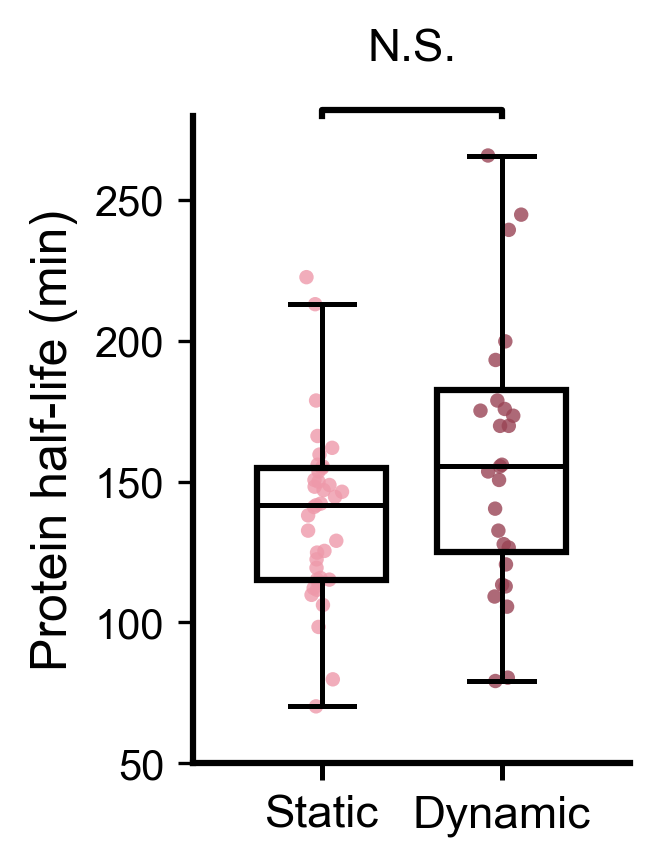

In [14]:
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 2    
    ax.plot([x1, x1, x2, x2],
            [y,  y_top, y_top, y],
            lw=1.5, 
            c="black",
            clip_on=False) 
    ax.text((x1 + x2)/2, 
            y_top * 1.05, 
            text,
            ha="center", 
            va="bottom", 
            fontsize=11,
           zorder=4)

# Prepare plot
fig, ax = plt.subplots(figsize=(2.3, 3))

positions = [1.0, 1.7]
group_data = [static_vals, dynamic_vals]
group_colors = [Y2H_COLOR_LIGHT, Y2H_COLOR_DARK]

# Scatter (jittered)
for pos, (vals, color) in zip(positions, zip(group_data, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.04, size=len(vals))
    ax.scatter(x_jitter, vals, s=12, color=color,
               alpha=0.8, edgecolor="none", zorder=2)

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_data,
    tick_labels=["Static,\nBottlenecks", "Dynamic,\nNon-\nbottlenecks"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)
        
# === 3. X-axis labels ===
ax.set_xticks(positions)
ax.set_xticklabels(["Static", "Dynamic"],
                       fontsize=11)
ax.tick_params(axis="x", length=4, width=1.2)

labs = ax.get_xticklabels()
labs[0].set_color("black")
labs[1].set_color("black")

# Styling
#ax.set_yscale("log")
ax.set_ylim(50, 280)
#ax.minorticks_off()
ax.set_ylabel('Protein half-life (min)', fontsize=12)
bracket_y = 280
bracket_h = 2

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

# Set clean y-limits: from 0 down to a bit below the lowest value
#y_min = min(y2h_hub_vals.min(), y2h_nothub_vals.min())
#y_max = max(y2h_hub_vals.max(), y2h_nothub_vals.max())

# Significance bracket
add_bracket_with_text(ax, positions[0], positions[1], y=280, text=stars)

# Bottom group label: "Y2H" style
trans = ax.get_xaxis_transform()
#ax.plot([1.0, 1.7], [-0.26, -0.26], transform=trans, clip_on=False, color=Y2H_COLOR, lw=2.5)
#ax.text(1.4, -0.28, "Y2H", transform=trans, ha="center", va="top",
#        fontsize=11, fontweight="bold", color=Y2H_COLOR)

plt.tight_layout()
plt.savefig("Supp5-F.svg", dpi=400, bbox_inches='tight')
plt.show()

## Supplement Fig 5G-H

* Create Box plots comparing stability metrices and melting point between static and dynamic bottleneck proteins (high betweenness centrality) in the Y2H network

In [15]:
# === Prepare Y2H Betweenness Hubs (top 10%) ===
y2h_hubs = filtered_nodes[
    filtered_nodes['Y2H_betweenness_centrality'] >= filtered_nodes['Y2H_betweenness_centrality'].quantile(0.9)
].copy()
y2h_hubs['in_complex'] = y2h_hubs['in_complex'].astype(bool)

# === Define the 4 stability metrics ===
stability_list = [
    ("Ghosh-Dill-dG",            "Ghosh-Dill ΔG"),
    ("cagiada-dG",               "Cagiada ΔG"),
    ("Rosetta_best_total_score", "Rosetta Total Score"),
    ("meltome-melting-point",    "Melting Point Tm (°C)"),
]

# === Extract clean values: Static vs Dynamic hubs ===
groups_step4 = []
for col, name in stability_list:
    if col == 'meltome-melting-point':
        data = y2h_hubs[y2h_hubs['meltome-fit-R2'] >= 0.9]   # High-quality meltome only
    else:
        data = y2h_hubs
    
    static_vals  = data[data['in_complex']][col].replace([np.inf, -np.inf], np.nan).dropna()
    dynamic_vals = data[~data['in_complex']][col].replace([np.inf, -np.inf], np.nan).dropna()
    
    groups_step4.append((name, static_vals, dynamic_vals))

print("=== BOOTSTRAPPED MEDIANS (95% CI) – Static vs Dynamic in Betweenness Hubs ===\n")
for name, static_vals, dynamic_vals in groups_step4:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data")
        continue
    m_s, lo_s, hi_s = bootstrap_ci_median(static_vals, random_state=42)
    m_d, lo_d, hi_d = bootstrap_ci_median(dynamic_vals, random_state=42)
    print(f"{name:30} | Static:  {m_s:6.2f} [{lo_s:.1f}, {hi_s:.1f}]  (n={len(static_vals)})")
    print(f"{'':30} | Dynamic: {m_d:6.2f} [{lo_d:.1f}, {hi_d:.1f}]  (n={len(dynamic_vals)})\n")

=== BOOTSTRAPPED MEDIANS (95% CI) – Static vs Dynamic in Betweenness Hubs ===



Ghosh-Dill ΔG                  | Static:  -10.95 [-11.8, -9.3]  (n=63)
                               | Dynamic: -11.81 [-12.7, -9.4]  (n=36)



Cagiada ΔG                     | Static:  -17.56 [-20.6, -14.0]  (n=63)
                               | Dynamic: -18.44 [-21.5, -14.4]  (n=36)



Rosetta Total Score            | Static:  -1004.93 [-1253.5, -756.1]  (n=63)
                               | Dynamic: -1067.26 [-1311.2, -773.1]  (n=36)



Melting Point Tm (°C)          | Static:   49.45 [47.2, 50.3]  (n=25)
                               | Dynamic:  49.99 [47.0, 52.2]  (n=22)



In [16]:
print("\n=== MANN–WHITNEY U TESTS (Static vs Dynamic in Betweenness Hubs) ===\n")

results = []
for name, static_vals, dynamic_vals in groups_step4:
    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print(f"{name:30}: insufficient data for test")
        results.append((name, np.nan, 1.0))
        continue
    
    u_stat, p_val = mannwhitneyu(static_vals, dynamic_vals, alternative='greater')
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
    
    print(f"{name:30} | U = {u_stat:6.0f}, p = {p_val:.2g} {stars}")
    print(f"{'':32} Static median = {np.median(static_vals):.2f}, Dynamic = {np.median(dynamic_vals):.2f}\n")
    
    results.append((name, u_stat, p_val))


=== MANN–WHITNEY U TESTS (Static vs Dynamic in Betweenness Hubs) ===

Ghosh-Dill ΔG                  | U =   1230, p = 0.24 N.S.
                                 Static median = -10.95, Dynamic = -11.81

Cagiada ΔG                     | U =   1268, p = 0.17 N.S.
                                 Static median = -17.56, Dynamic = -18.44

Rosetta Total Score            | U =   1183, p = 0.36 N.S.
                                 Static median = -1004.93, Dynamic = -1067.26

Melting Point Tm (°C)          | U =    250, p = 0.7 N.S.
                                 Static median = 49.45, Dynamic = 49.99



/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_35271/1897233743.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: Supp5G-J.1.svg


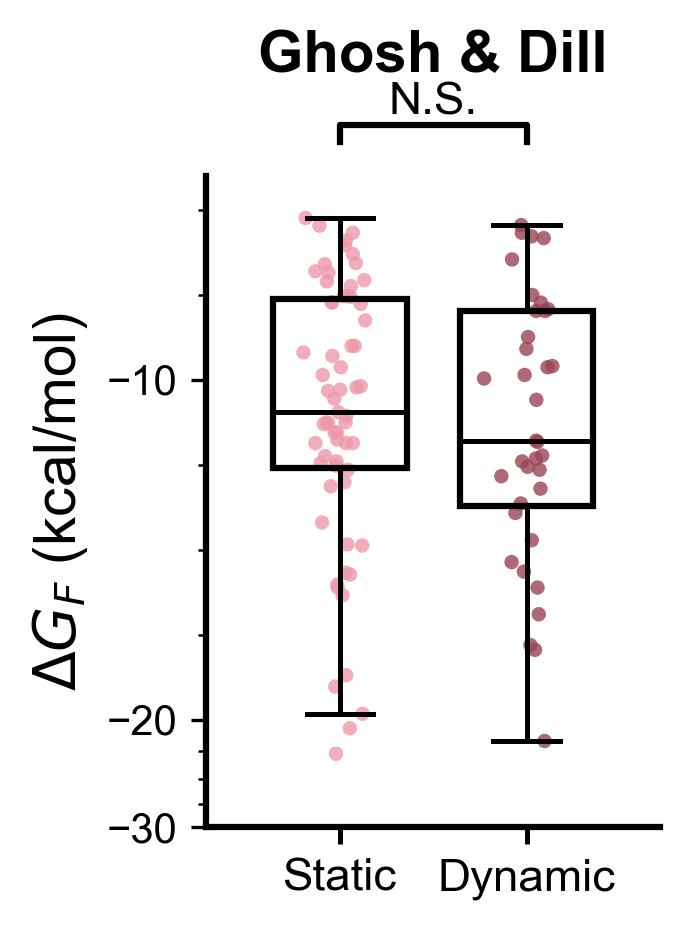

Saved: Supp5G-J.2.svg


/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_35271/1897233743.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


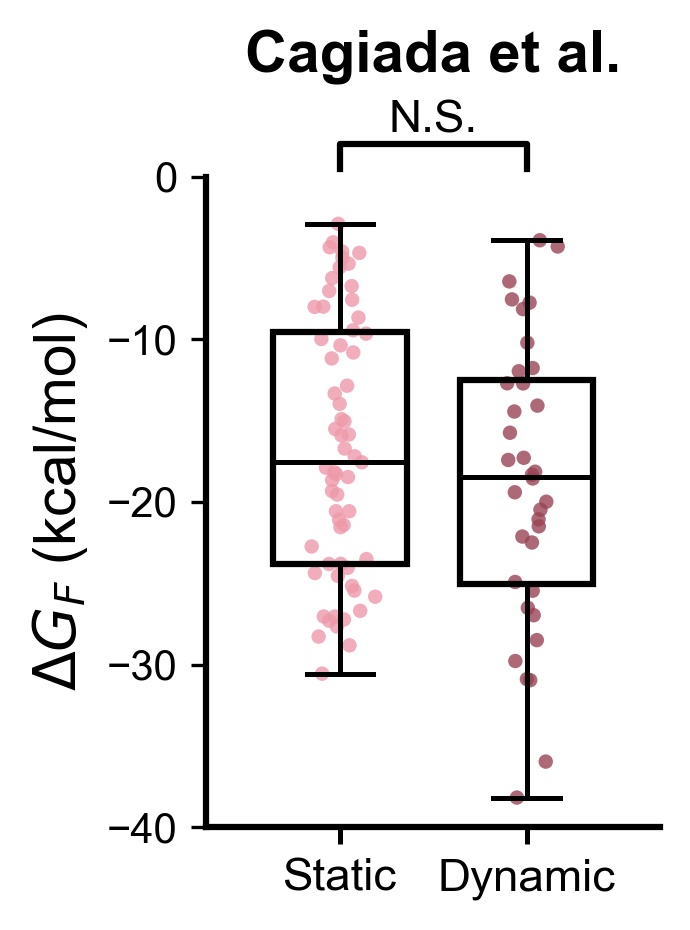

/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_35271/1897233743.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: Supp5G-J.3.svg


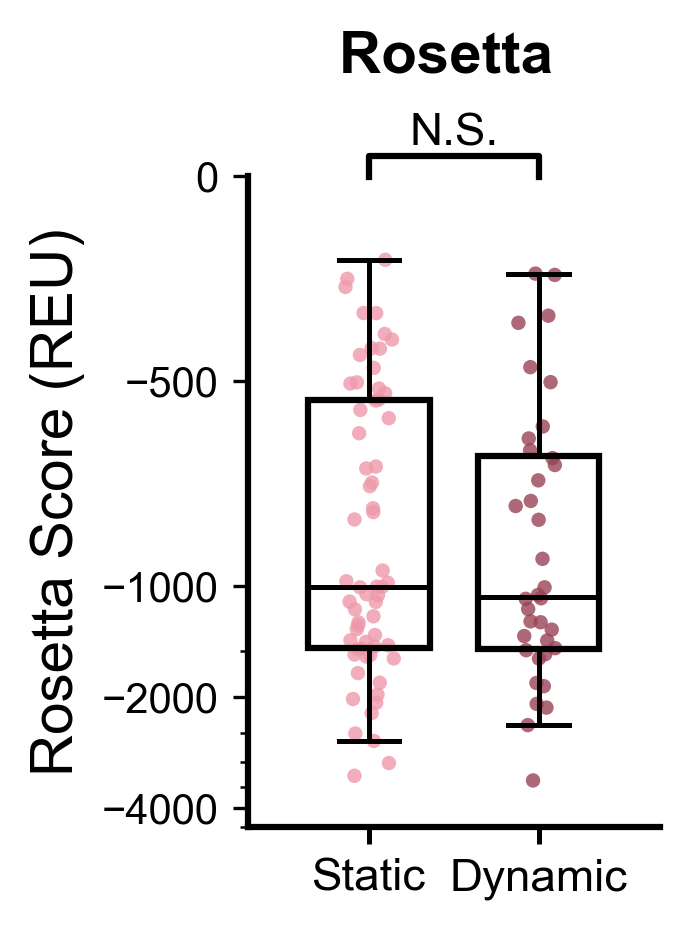

/var/folders/62/56bdxfp95bl8fmn_37yc9g080000gn/T/ipykernel_35271/1897233743.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: Supp5G-J.4.svg


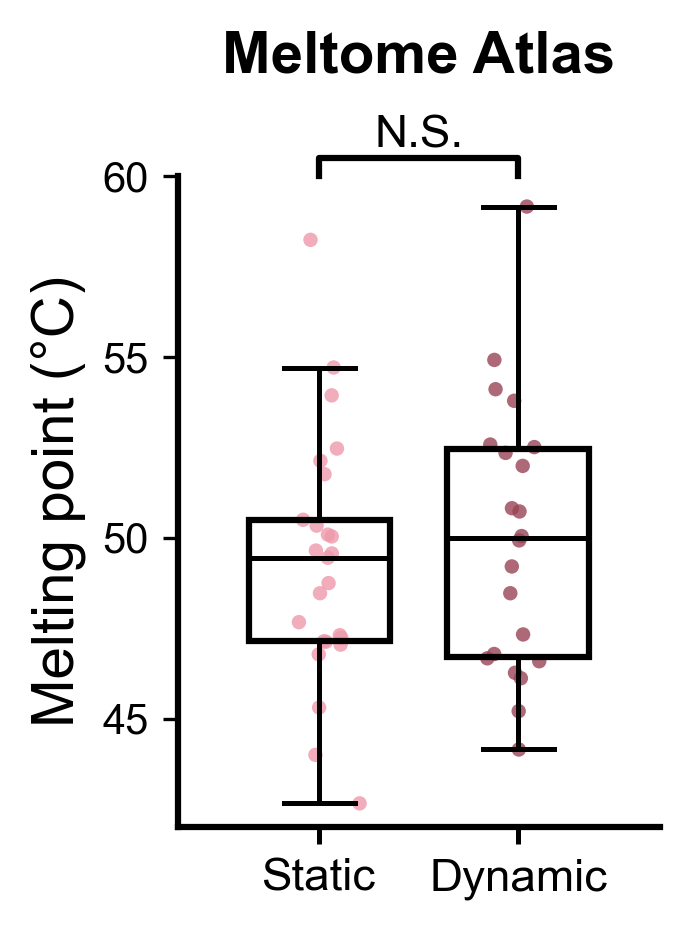

In [17]:
def draw_significance(ax, x1, x2, y, h, text):
    """
    Draws a straight bracket + text at EXACT y position and height h.
    - x1, x2 = x-coordinates of the two groups
    - y = vertical position of the bracket
    - h = height of the vertical bracket lines
    - text = significance stars
    """
    ax.plot([x1, x1, x2, x2],
            [y, y + h, y + h, y],
            lw=1.5, color="black", clip_on=False)
    
    ax.text((x1 + x2) / 2, y + h*1.1, text,
            ha="center", va="bottom",
            fontsize=11)


def base_box_scatter(ax, static_vals, dynamic_vals):
    positions = [1.0, 1.7]

    # === 1. Scatter ===
    for pos, vals, color in zip(
        positions,
        [static_vals, dynamic_vals],
        [Y2H_COLOR_LIGHT, Y2H_COLOR_DARK]
    ):
        x_jitter = pos + np.random.normal(0, 0.05, len(vals))
        ax.scatter(x_jitter, vals, s=12, alpha=0.8,
                   color=color, edgecolor="none", zorder=2)

    # === 2. Boxplot ===
    bp = ax.boxplot(
        [static_vals.values, dynamic_vals.values],
        positions=positions,
        labels=["Static", "Dynamic"],
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        zorder=3
    )

    for box in bp["boxes"]:
        box.set_facecolor("none")
        box.set_edgecolor("black")
        box.set_linewidth(1.5)

    for element in ["whiskers", "caps", "medians"]:
        plt.setp(bp[element], color="black", linewidth=1.2)

    # === 3. X-axis labels ===
    ax.set_xticks(positions)
    ax.set_xticklabels(["Static", "Dynamic"],
                       fontsize=11)
    ax.tick_params(axis="x", length=4, width=1.2)

    labs = ax.get_xticklabels()
    labs[0].set_color("black")
    labs[1].set_color("black")

    #  === 4. Spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    return positions

figure_counter = 1
for stab_name, static_vals, dynamic_vals in groups_step4:

    if len(static_vals) < 5 or len(dynamic_vals) < 5:
        print("Skipping:", stab_name)
        continue

    fig, ax = plt.subplots(figsize=(2.4, 3.2))

    #  === 5. Base scatter+boxplot
    positions = base_box_scatter(ax, static_vals, dynamic_vals)
    ax.set_ylabel(stab_name, fontsize=11)
    ax.set_title("", fontsize=11)

    #  === 6. Metric-specific axis rules
    if "Rosetta" in stab_name:
        #ax.set_yscale("symlog", linthresh=10)
        ax.set_ylabel("Rosetta Score (REU)", fontsize=14)
        ax.set_title("Rosetta ", fontweight='bold')
        ax.set_yscale("symlog", linthresh=1000)
        ax.set_ylim(-4500, 0)
        ax.set_yticks([-4000, -2000, -1000, -500, 0])
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
        #ax.minorticks_on()
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        bracket_y = -2   
        bracket_h = 50 

    elif "Meltome" in stab_name or "Tm" in stab_name:
        ax.set_ylabel(r"Melting point (°C)", fontsize=14)
        ax.set_title("Meltome Atlas", fontweight='bold')
        ax.set_ylim(42, 60)
        ax.set_yticks([45, 50, 55, 60])
        bracket_y = 60    
        bracket_h = 0.5

    elif "Cagiada" in stab_name:
        ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=14)
        ax.set_title("Cagiada et al.", fontweight='bold')
        ax.set_ylim(-40, 0)
        ax.set_yticks([0, -10, -20, -30, -40])
        bracket_y = 0.5
        bracket_h = 1.5
        
    elif "Ghosh-Dill" in stab_name:
        ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=14)
        ax.set_title("Ghosh & Dill", fontweight='bold')
        ax.set_yscale("symlog", linthresh=20)
        ax.set_ylim(-30, -4)
        ax.set_yticks([-10, -20, -30])
        ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
        #ax.minorticks_on()
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        bracket_y = -3
        bracket_h = 0.5
        
    #  === 7. Significance stars
    p_val = [r[2] for r in results if r[0] == stab_name][0]
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "N.S."
    draw_significance(ax, positions[0], positions[1], bracket_y, bracket_h, stars)

    #  === 8. Y2H label below plot
    trans = ax.get_xaxis_transform()
    #ax.plot([1.0, 1.7], [-0.24, -0.24], transform=trans,
    #        clip_on=False, color=Y2H_COLOR, lw=1.5)
    #ax.text(1.4, -0.26, "Y2H", transform=trans,
    #        ha="center", va="top", fontsize=10,
    #        fontweight="bold", color=Y2H_COLOR)

    # === 9. Save
    plt.tight_layout()
    out = f"Supp5G-J.{figure_counter}.svg"
    plt.savefig(out, dpi=400, bbox_inches="tight")
    print("Saved:", out)

    figure_counter += 1
    plt.show()